<a href="https://colab.research.google.com/github/AliRaddman/divar-ml-project/blob/main/notebooks/work/hypothesis_ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" align="right">

# آزمون فرض - بخش علی

در این نوت‌بوک، آزمون فرض مربوط به مقایسه‌ی میانگین مساحت خانه‌های مسکونی در کلان‌شهرها و شهرهای کوچک/روستاها انجام می‌شود.

هدف اصلی این است که بررسی کنیم آیا میانگین مساحت خانه‌های مسکونی در کلان‌شهرها به‌صورت معنادار کمتر از شهرهای کوچک و روستاهاست یا نه.

</div>

In [12]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12, 6)

print("Setup completed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup completed.


<div dir="rtl" align="right">

## خواندن داده‌ی نهایی و فایل دسته‌بندی شهرها

در این بخش، آخرین خروجی preprocessing و فایل کمکی دسته‌بندی شهرها را می‌خوانیم.  
برای اتصال این دو فایل، ابتدا ستون‌های موجود در فایل شهرها را بررسی می‌کنیم.

</div>

In [13]:
data_path = "/content/drive/MyDrive/divar_project/cleaned_step3_geo.parquet"
city_path = "/content/drive/MyDrive/Divar Dataset/iran_city_classification.csv"

df = pd.read_parquet(data_path)
city_df = pd.read_csv(city_path)

print("Main data shape:", df.shape)
print("City classification shape:", city_df.shape)

print("\nMain data columns related to city:")
print([col for col in df.columns if "city" in col.lower()])

print("\nCity classification columns:")
print(city_df.columns.tolist())

display(city_df.head())

Main data shape: (999943, 85)
City classification shape: (240, 2)

Main data columns related to city:
['city_slug', 'regular_person_capacity']

City classification columns:
['نام شهر', 'دسته\u200cبندی']


,نام شهر,دسته‌بندی
0,karaj,کلان‌شهر
1,tehran,کلان‌شهر
2,mashhad,کلان‌شهر
3,ahvaz,کلان‌شهر
4,kermanshah,کلان‌شهر


<div dir="rtl" align="right">

## اتصال دسته‌بندی شهرها به دیتای اصلی

در این بخش، فایل دسته‌بندی شهرها را با دیتای اصلی ادغام می‌کنیم.  
ستون `city_slug` در دیتای اصلی معادل ستون `نام شهر` در فایل دسته‌بندی شهرهاست.

بعد از ادغام، بررسی می‌کنیم چه تعداد ردیف دسته‌بندی شهر دریافت کرده‌اند و چه تعداد بدون دسته‌بندی مانده‌اند.

</div>

In [14]:
city_df_clean = city_df.rename(columns={
    "نام شهر": "city_slug",
    "دسته‌بندی": "city_class"
}).copy()

city_df_clean["city_slug"] = city_df_clean["city_slug"].astype(str).str.strip()
city_df_clean["city_class"] = city_df_clean["city_class"].astype(str).str.strip()

df_hyp = df.merge(
    city_df_clean,
    on="city_slug",
    how="left"
)

print("Shape after merge:", df_hyp.shape)

print("\nCity class value counts:")
print(df_hyp["city_class"].value_counts(dropna=False))

print("\nNumber of rows without city_class:")
print(df_hyp["city_class"].isna().sum())

print("\nSample unmatched city_slug values:")
display(
    df_hyp.loc[df_hyp["city_class"].isna(), "city_slug"]
    .value_counts()
    .head(20)
)

Shape after merge: (999943, 86)

City class value counts:
city_class
شهر کوچک    498474
کلان‌شهر    464748
NaN          36721
Name: count, dtype: int64

Number of rows without city_class:
36721

Sample unmatched city_slug values:


,count
city_slug,
langarud,1461
andimeshk,1361
qorveh,867
garmsar,839
bandar-Imam-khomeini,786
takestan,783
fasa-city,774
aligudarz,744
khoshkbijar,733


<div dir="rtl" align="right">

## بررسی دسته‌های مسکونی و ستون مساحت

برای آزمون فرض، فقط آگهی‌های مسکونی را وارد تحلیل می‌کنیم.  
در این بخش، دسته‌های موجود در `cat2_slug` و `cat3_slug` و همچنین وضعیت ستون‌های مربوط به مساحت بررسی می‌شوند.

</div>

In [15]:
check_cols = [
    "cat2_slug",
    "cat3_slug",
    "building_size",
    "building_size_pos",
    "city_class"
]

print("Missing values in selected columns:")
print(df_hyp[check_cols].isna().sum())

print("\ncat2_slug values:")
print(df_hyp["cat2_slug"].value_counts(dropna=False))

print("\ncat3_slug values:")
print(df_hyp["cat3_slug"].value_counts(dropna=False))

print("\nBuilding size statistics:")
print(df_hyp[["building_size", "building_size_pos"]].describe())

print("\nCity class values:")
print(df_hyp["city_class"].value_counts(dropna=False))

Missing values in selected columns:
cat2_slug                0
cat3_slug                0
building_size            0
building_size_pos        0
city_class           36721
dtype: int64

cat2_slug values:
cat2_slug
residential-sell        558692
residential-rent        276528
commercial-rent          76564
commercial-sell          38860
temporary-rent           29897
real-estate-services     19402
Name: count, dtype: int64

cat3_slug values:
cat3_slug
apartment-sell                        303372
apartment-rent                        211853
plot-old                              133570
house-villa-sell                      121750
house-villa-rent                       64675
shop-rent                              45993
shop-sell                              21855
office-rent                            21416
suite-apartment                        16460
presell                                15780
villa                                  12898
industry-agriculture-business-sell     11850
indust

<div dir="rtl" align="right">

## ساخت دیتای پایه برای آزمون فرض

برای آزمون فرض، فقط آگهی‌های مسکونی واضح را نگه می‌داریم.  
در این مرحله، آگهی‌هایی که دسته‌بندی شهر ندارند حذف می‌شوند و فقط دسته‌های مربوط به آپارتمان و خانه/ویلا وارد تحلیل می‌شوند.

همچنین قبل از اجرای آزمون، توزیع مساحت بررسی می‌شود تا برای حذف داده‌های پرت تصمیم بگیریم.

</div>

In [16]:
residential_home_cat3 = [
    "apartment-sell",
    "apartment-rent",
    "house-villa-sell",
    "house-villa-rent",
]

hyp_base = df_hyp[
    (df_hyp["cat3_slug"].isin(residential_home_cat3)) &
    (df_hyp["city_class"].isin(["کلان‌شهر", "شهر کوچک"])) &
    (df_hyp["building_size_pos"].notna()) &
    (df_hyp["building_size_pos"] > 0)
].copy()

print("Base hypothesis data shape:", hyp_base.shape)

print("\ncat3_slug distribution:")
print(hyp_base["cat3_slug"].value_counts())

print("\ncity_class distribution:")
print(hyp_base["city_class"].value_counts())

print("\nBuilding size quantiles:")
display(
    hyp_base["building_size_pos"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995, 0.999])
    .reset_index()
    .rename(columns={"index": "quantile", "building_size_pos": "building_size"})
)

print("\nBuilding size statistics by city_class:")
display(
    hyp_base
    .groupby("city_class")["building_size_pos"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

Base hypothesis data shape: (684411, 86)

cat3_slug distribution:
cat3_slug
apartment-sell                        299915
apartment-rent                        208930
house-villa-sell                      114474
house-villa-rent                       61092
industry-agriculture-business-rent         0
industry-agriculture-business-sell         0
office-rent                                0
office-sell                                0
partnership                                0
plot-old                                   0
presell                                    0
shop-rent                                  0
shop-sell                                  0
suite-apartment                            0
villa                                      0
workspace                                  0
Name: count, dtype: int64

city_class distribution:
city_class
کلان‌شهر    358358
شهر کوچک    326053
Name: count, dtype: int64

Building size quantiles:


,quantile,building_size
0,0.010,35.0
1,0.050,50.0
2,0.250,75.0
3,0.500,100.0
4,0.750,134.0
5,0.950,250.0
6,0.990,520.0
7,0.995,1000.0
8,0.999,111111.0



Building size statistics by city_class:


,city_class,count,mean,median,std,min,max
0,شهر کوچک,326053,1782.840379,100.0,85629.001975,1.0,10000000.0
1,کلان‌شهر,358358,766.641716,100.0,53095.754370,1.0,10000000.0


<div dir="rtl" align="right">

## حذف متراژهای پرت و ساخت دیتای نهایی آزمون

در داده‌ی پایه، مقدارهای بسیار بزرگ و غیرواقعی برای مساحت دیده شد.  
برای جلوگیری از اثرگذاری داده‌های پرت روی میانگین و نتیجه آزمون، فقط آگهی‌هایی نگه داشته می‌شوند که مساحت آن‌ها بین `20` تا `1000` متر مربع باشد.

این بازه برای آگهی‌های مسکونی شامل آپارتمان و خانه/ویلا قابل دفاع است و مقدارهای بسیار کوچک یا بسیار بزرگ را از تحلیل حذف می‌کند.

</div>

In [17]:
hyp_clean = hyp_base[
    (hyp_base["building_size_pos"] >= 20) &
    (hyp_base["building_size_pos"] <= 1000)
].copy()

print("Rows before outlier filtering:", len(hyp_base))
print("Rows after outlier filtering:", len(hyp_clean))
print("Rows removed:", len(hyp_base) - len(hyp_clean))

print("\nCity class distribution after filtering:")
print(hyp_clean["city_class"].value_counts())

print("\nBuilding size statistics by city_class after filtering:")
summary_by_city_class = (
    hyp_clean
    .groupby("city_class")["building_size_pos"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

display(summary_by_city_class)

print("\nBuilding size quantiles after filtering:")
display(
    hyp_clean["building_size_pos"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .reset_index()
    .rename(columns={"index": "quantile", "building_size_pos": "building_size"})
)

Rows before outlier filtering: 684411
Rows after outlier filtering: 678458
Rows removed: 5953

City class distribution after filtering:
city_class
کلان‌شهر    355740
شهر کوچک    322718
Name: count, dtype: int64

Building size statistics by city_class after filtering:


,city_class,count,mean,median,std,min,max
0,شهر کوچک,322718,117.189810,100.0,77.367271,20.0,1000.0
1,کلان‌شهر,355740,115.381756,100.0,76.740600,20.0,1000.0



Building size quantiles after filtering:


,quantile,building_size
0,0.01,40.0
1,0.05,50.0
2,0.25,75.0
3,0.50,100.0
4,0.75,132.0
5,0.95,240.0
6,0.99,431.0


<div dir="rtl" align="right">

## اجرای آزمون فرض

در این آزمون بررسی می‌کنیم آیا میانگین مساحت خانه‌های مسکونی در کلان‌شهرها کمتر از شهرهای کوچک است یا نه.

فرض صفر و فرض مقابل به شکل زیر تعریف می‌شوند:

`H0`: میانگین مساحت خانه‌های مسکونی در کلان‌شهرها کمتر از شهرهای کوچک نیست.

`H1`: میانگین مساحت خانه‌های مسکونی در کلان‌شهرها کمتر از شهرهای کوچک است.

از آن‌جا که دو گروه مستقل هستند و برابر بودن واریانس‌ها را فرض نمی‌کنیم، از آزمون `Welch t-test` یک‌طرفه استفاده می‌کنیم.

</div>

In [18]:
metro_area = hyp_clean.loc[
    hyp_clean["city_class"] == "کلان‌شهر",
    "building_size_pos"
].astype(float)

small_city_area = hyp_clean.loc[
    hyp_clean["city_class"] == "شهر کوچک",
    "building_size_pos"
].astype(float)

# آزمون Welch t-test یک‌طرفه
# alternative="less" یعنی بررسی می‌کنیم آیا میانگین گروه اول کمتر از گروه دوم است
t_statistic, p_value = stats.ttest_ind(
    metro_area,
    small_city_area,
    equal_var=False,
    alternative="less"
)

# محاسبه اختلاف میانگین
mean_metro = metro_area.mean()
mean_small_city = small_city_area.mean()
mean_difference = mean_metro - mean_small_city

# محاسبه Cohen's d برای اندازه اثر
n_metro = len(metro_area)
n_small_city = len(small_city_area)

std_metro = metro_area.std(ddof=1)
std_small_city = small_city_area.std(ddof=1)

pooled_std = np.sqrt(
    ((n_metro - 1) * std_metro**2 + (n_small_city - 1) * std_small_city**2) /
    (n_metro + n_small_city - 2)
)

cohens_d = mean_difference / pooled_std

test_result = pd.DataFrame({
    "metric": [
        "metro_count",
        "small_city_count",
        "metro_mean",
        "small_city_mean",
        "mean_difference_metro_minus_small_city",
        "t_statistic",
        "p_value",
        "cohens_d"
    ],
    "value": [
        n_metro,
        n_small_city,
        mean_metro,
        mean_small_city,
        mean_difference,
        t_statistic,
        p_value,
        cohens_d
    ]
})

display(test_result)

,metric,value
0,metro_count,3.557400e+05
1,small_city_count,3.227180e+05
2,metro_mean,1.153818e+02
3,small_city_mean,1.171898e+02
4,mean_difference_metro_minus_small_city,-1.808053e+00
5,t_statistic,-9.650356e+00
6,p_value,2.457360e-22
7,cohens_d,-2.346923e-02


<div dir="rtl" align="right">

## مقایسه تصویری مساحت خانه‌ها در دو گروه شهری

برای درک بهتر نتیجه آزمون فرض، توزیع مساحت خانه‌های مسکونی در دو گروه `کلان‌شهر` و `شهر کوچک` را با نمودار جعبه‌ای مقایسه می‌کنیم.

</div>

/tmp/ipykernel_22421/2864670833.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


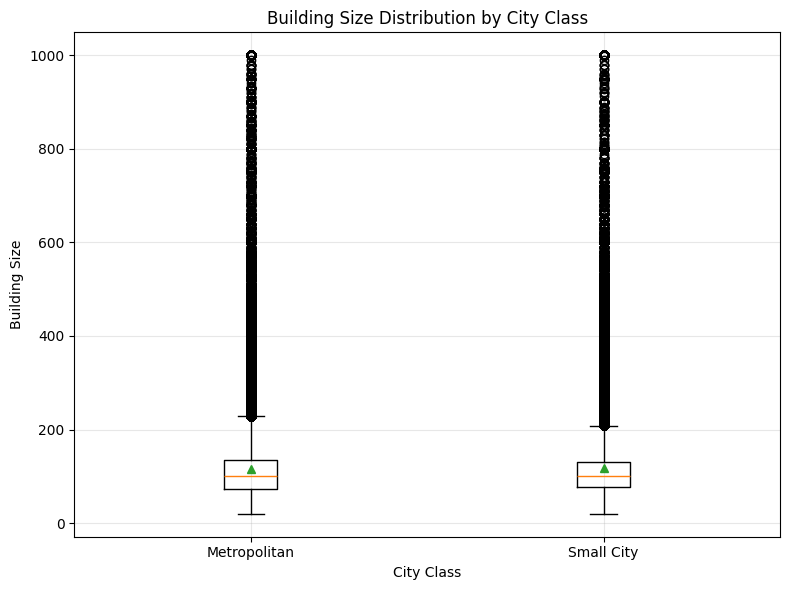

In [19]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [metro_area, small_city_area],
    labels=["Metropolitan", "Small City"],
    showmeans=True
)

plt.title("Building Size Distribution by City Class")
plt.xlabel("City Class")
plt.ylabel("Building Size")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نمودار جعبه‌ای بزرگ‌نمایی‌شده

در نمودار قبلی، تعداد زیادی مقدار بزرگ باعث شد بخش اصلی توزیع به‌خوبی دیده نشود.  
برای نمایش واضح‌تر، یک نسخه‌ی بزرگ‌نمایی‌شده از نمودار رسم می‌کنیم و محور عمودی را تا `300` متر مربع محدود می‌کنیم.

</div>

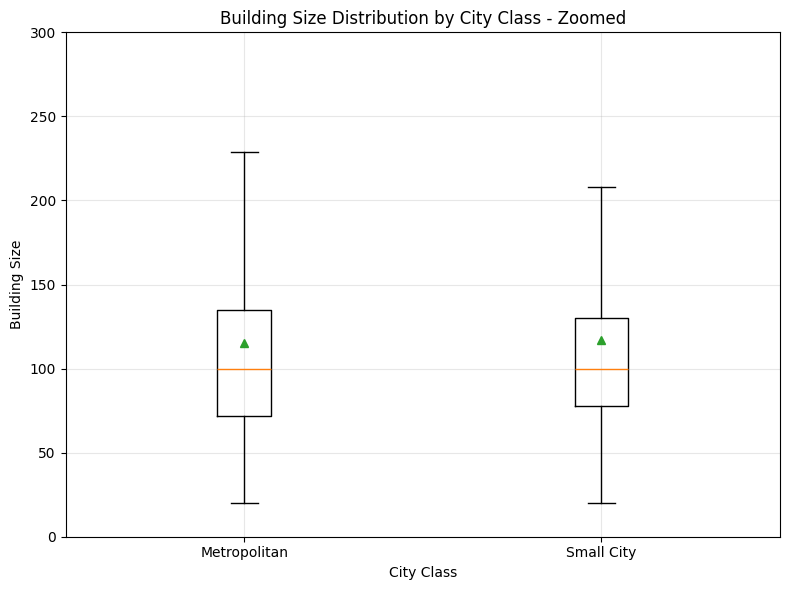

In [20]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [metro_area, small_city_area],
    tick_labels=["Metropolitan", "Small City"],
    showmeans=True,
    showfliers=False
)

plt.title("Building Size Distribution by City Class - Zoomed")
plt.xlabel("City Class")
plt.ylabel("Building Size")
plt.ylim(0, 300)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
print("cat2_slug values in hyp_clean:")
print(hyp_clean["cat2_slug"].value_counts())

print("\ncat3_slug values in hyp_clean:")
print(hyp_clean["cat3_slug"].value_counts())

print("\nAny non-residential cat2?")
print(
    hyp_clean[
        ~hyp_clean["cat2_slug"].isin(["residential-sell", "residential-rent"])
    ][["cat2_slug", "cat3_slug"]].drop_duplicates()
)

cat2_slug values in hyp_clean:
cat2_slug
residential-sell        410790
residential-rent        267668
commercial-sell              0
commercial-rent              0
real-estate-services         0
temporary-rent               0
Name: count, dtype: int64

cat3_slug values in hyp_clean:
cat3_slug
apartment-sell                        299273
apartment-rent                        207866
house-villa-sell                      111517
house-villa-rent                       59802
industry-agriculture-business-rent         0
industry-agriculture-business-sell         0
office-rent                                0
office-sell                                0
partnership                                0
plot-old                                   0
presell                                    0
shop-rent                                  0
shop-sell                                  0
suite-apartment                            0
villa                                      0
workspace                     

<div dir="rtl" align="right">

### بررسی نهایی مسکونی بودن داده‌های آزمون

برای اطمینان از اینکه آگهی‌های غیرمسکونی وارد آزمون فرض نشده باشند، مقادیر `cat2_slug` و `cat3_slug` در دیتای نهایی آزمون بررسی شد.

نتیجه نشان داد که دیتای آزمون فقط شامل دو دسته‌ی سطح دو زیر است:

`residential-sell`

`residential-rent`

همچنین در سطح سه، فقط آگهی‌های مربوط به آپارتمان و خانه/ویلا باقی مانده‌اند:

`apartment-sell`

`apartment-rent`

`house-villa-sell`

`house-villa-rent`

بنابراین آگهی‌هایی مثل مغازه، دفتر کار، املاک صنعتی، خدمات املاک و اجاره موقت وارد آزمون نشده‌اند. بازه‌ی متراژ مورد استفاده نیز `20` تا `1000` متر مربع در نظر گرفته شد تا مقدارهای بسیار کوچک یا بسیار بزرگ روی نتیجه اثر نگذارند.

</div>

<div dir="rtl" align="right">

### جمع‌بندی نهایی آزمون فرض ۱

در این آزمون بررسی شد که آیا میانگین مساحت خانه‌های مسکونی در کلان‌شهرها کمتر از شهرهای کوچک است یا نه.

برای انجام آزمون، ابتدا فایل دسته‌بندی شهرها به دیتای اصلی متصل شد. سپس فقط آگهی‌های مسکونی واضح وارد تحلیل شدند؛ یعنی آگهی‌های مربوط به آپارتمان و خانه/ویلا در دسته‌های زیر:

`apartment-sell`

`apartment-rent`

`house-villa-sell`

`house-villa-rent`

همچنین برای جلوگیری از اثرگذاری مقدارهای پرت، فقط آگهی‌هایی نگه داشته شدند که متراژ آن‌ها بین `20` تا `1000` متر مربع بود.

فرض‌های آزمون به شکل زیر تعریف شدند:

`H0`: میانگین مساحت خانه‌های مسکونی در کلان‌شهرها کمتر از شهرهای کوچک نیست.

`H1`: میانگین مساحت خانه‌های مسکونی در کلان‌شهرها کمتر از شهرهای کوچک است.

برای مقایسه دو گروه از آزمون `Welch t-test` یک‌طرفه استفاده شد، چون دو گروه مستقل هستند و برابر بودن واریانس‌ها فرض نشده است.

نتایج اصلی آزمون:

`metro_count = 355,740`

`small_city_count = 322,718`

`metro_mean = 115.38`

`small_city_mean = 117.19`

`mean_difference = -1.81`

`t_statistic = -9.65`

`p_value = 2.45e-22`

`cohens_d = -0.023`

از آن‌جا که مقدار `p_value` بسیار کمتر از `0.05` است، فرض صفر رد می‌شود. بنابراین از نظر آماری، داده‌ها نشان می‌دهند که میانگین مساحت خانه‌های مسکونی در کلان‌شهرها کمتر از شهرهای کوچک است.

با این حال، اختلاف میانگین فقط حدود `1.81` متر مربع است و مقدار `Cohen's d` نیز بسیار کوچک است. بنابراین با وجود معنادار بودن آماری، اندازه اثر بسیار ضعیف است و اختلاف از نظر عملی یا بازار املاک چندان بزرگ نیست.

در نتیجه، فرضیه از نظر آماری تأیید می‌شود، اما شدت تفاوت بین دو گروه کم است.

</div>